### 第6章 阈值处理
- 阈值处理是指剔除图像内像素值高于或低于一定值的像素点
#### 6.1 阈值函数
- `retval, dst = cv2.threshold(src, thresh, maxval, type)`, 其中
    - retval 代表返回的阈值
    - dst 代表阈值分割后的图像，类型与大小与原始图像相同
    - src 代表原始图像，可以是多通道、8位或32位浮点型数值
    - thresh 代表设定的阈值
    - maxval 表示当`type`设为`THRESH_BINARY`或`THRESH_BINARY_INV`时，需要设定的最大值

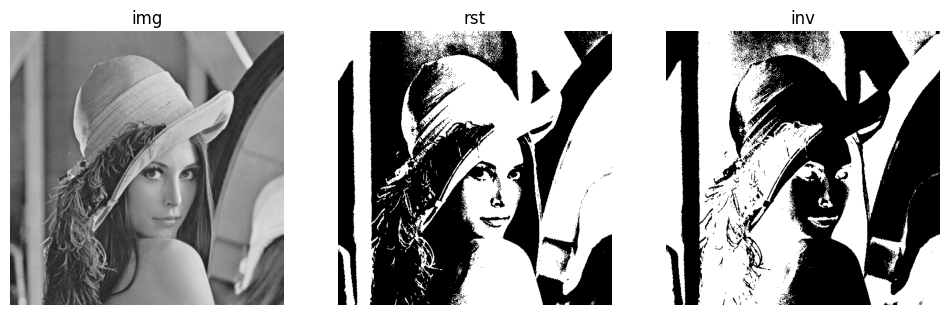

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import cv2

# 二值化阈值处理和反二值化阈值处理，将原始图像处理为仅有两个值的二值图像
img = cv2.imread("lena.bmp")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
t, rst = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
k, inv = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(img_rgb)
plt.title("img")
plt.axis("off")

plt.subplot(132)
plt.imshow(rst)
plt.title("rst")
plt.axis("off")

plt.subplot(133)
plt.imshow(inv)
plt.title("inv")
plt.axis("off")
plt.show()

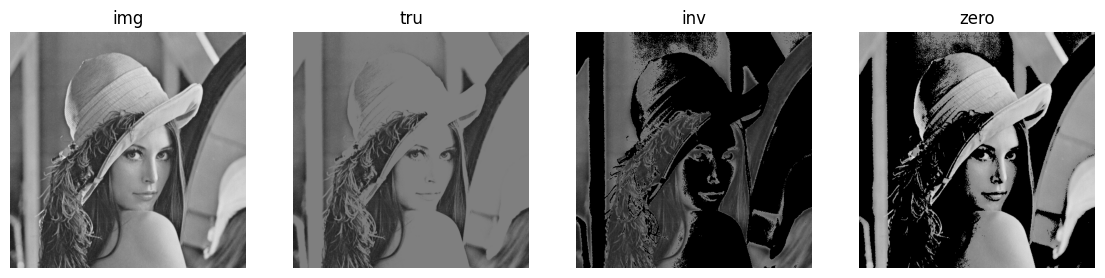

In [44]:
# 截断阈值处理：大于阈值的像素点设置为阈值，小于等于阈值的像素点保持不变
# 超阈值零处理：大于阈值的像素点设为0，小于等于阈值的像素点保持不变
# 低阈值零处理：小于等于阈值的像素点设为0，大于阈值的像素点保持不变
img = cv2.imread("lena.bmp")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
_, tru = cv2.threshold(img, 127, 255, cv2.THRESH_TRUNC)
_, inv = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO_INV)
_, zero = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO)

plt.figure(figsize=(14, 4))
plt.subplot(141)
plt.imshow(img_rgb)
plt.title("img")
plt.axis("off")

plt.subplot(142)
plt.imshow(tru)
plt.title("tru")
plt.axis("off")

plt.subplot(143)
plt.imshow(inv)
plt.title("inv")
plt.axis("off")

plt.subplot(144)
plt.imshow(zero)
plt.title("zero")
plt.axis("off")
plt.show()

#### 6.2 Otsu 处理
- Otsu，也称为最大类间方差法，该方法使用聚类的思想，把图像中所有像素点的像素值按灰度级分成两组，确保：
    - 每组之间灰度值差异最大
    - 每组之内灰度值差异最小
- 注意：在使用Otsu方法时，要把阈值设为0

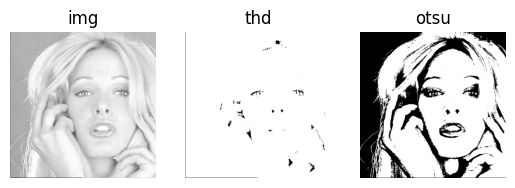

In [ ]:
import cv2
img = cv2.imread("tiffany.bmp", 0)
t1, thd = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)   # 普通二值化阈值处理
t2, otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)    # Otsu 二值化阈值处理

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
thd = cv2.cvtColor(thd, cv2.COLOR_BGR2RGB)
otsu = cv2.cvtColor(otsu, cv2.COLOR_BGR2RGB)

plt.subplot(131)
plt.imshow(img)
plt.title("img")
plt.axis("off")

# 以127为阈值进行二值化处理，得到大量白色区域
plt.subplot(132)
plt.imshow(thd)
plt.title("thd")
plt.axis("off")

# Otsu 二值化处理自动计算出最佳阈值，得到较好的二值化结果
plt.subplot(133)
plt.imshow(otsu)
plt.title("otsu")
plt.axis("off")
plt.show()

#### 6.3 自适应阈值处理
- 通过计算每个像素点周围邻近区域的加权平均值获得阈值，并使用该阈值对当前像素点进行处理，能够更好地处理明暗差异较大的图像
- `dst = cv2.adaptiveThreshold(src, maxValue, adaptiveMethod, thresholdType, blockSize, C)`, 其中
    - dst 代表自适应阈值处理的结果，类型与大小与原始图像相同
    - src 代表原始图像，必须是8位单通道图像
    - maxValue 代表最大值
    - adaptiveMethod 表示自适应方法
        - cv2.ADAPTIVE_THRESH_MEAN_C：邻域所有像素点的权重值一致
        - cv2.ADAPTIVE_THRESH_GAUSSIAN_C：通过高斯方程得到权重值，距离中心点越近的像素点权重值越大
    - thresholdType 代表阈值处理方式，只能是`cv2.THRESH_BINARY`或`cv2.THRESH_BINARY_INV`其中一个
    - blockSize 表示一个像素在计算阈值时所使用的邻域尺寸，通常为3、5、7
    - C 是常量

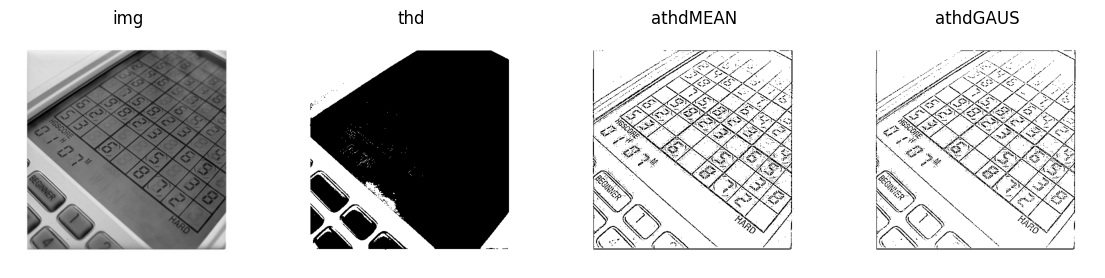

In [54]:
import cv2
img = cv2.imread("computer.jpg", cv2.IMREAD_GRAYSCALE) # 必须以单通道灰度模式读取图像
t1, thd=cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
athdMEAN = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 3, 5)
athdGAUS = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 3, 5)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
thd = cv2.cvtColor(thd, cv2.COLOR_BGR2RGB)
athdMEAN = cv2.cvtColor(athdMEAN, cv2.COLOR_BGR2RGB)
athdGAUS = cv2.cvtColor(athdGAUS, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 4))
plt.subplot(141)
plt.imshow(img)
plt.title("img")
plt.axis("off")

plt.subplot(142)
plt.imshow(thd)
plt.title("thd")
plt.axis("off")

plt.subplot(143)
plt.imshow(athdMEAN)
plt.title("athdMEAN")
plt.axis("off")

plt.subplot(144)
plt.imshow(athdGAUS)
plt.title("athdGAUS")
plt.axis("off")
plt.show()